In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
from tqdm import tqdm
import random
import json

/home/bhanselman/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
%matplotlib inline

In [3]:
table = pd.read_table('/home/bibih/bl-test/c_0002_sed.out', skiprows=1, delimiter='|').dropna()
unspliced_table = table[table.iloc[:, 8] == 64]
unspliced_table

/tmp/ipykernel_3348991/1735801245.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_table('/home/bibih/bl-test/c_0002_sed.out', skiprows=1, delimiter='|').dropna()


,id,observation_id,format,size,freq_low,freq_high,location,deleted,coarse_channels,fch1,foff,nbits,tstart,tsamp,nsamples,nchans,nifs
1,3173,317703.0,hdf5,50159266.0,3751.466274,3938.966274,/datag/pipeline/AGBT21A_996_44/blc36/blc36_gu...,f,64.0,3938.964844,-0.002861,32.0,59383.872558,1.073742,279.0,65536.0,1.0
2,4428,317681.0,hdf5,6777634.0,8251.466274,8438.966274,/datag/pipeline/AGBT21A_996_44/blc00/blc00_gu...,f,64.0,8438.964844,-0.002861,32.0,59383.810729,1.073742,37.0,65536.0,1.0
3,4431,317682.0,hdf5,12424790.0,8251.466274,8438.966274,/datag/pipeline/AGBT21A_996_44/blc00/blc00_gu...,f,64.0,8438.964844,-0.002861,32.0,59383.814271,1.073742,68.0,65536.0,1.0
4,4434,317692.0,hdf5,20254497.0,8251.466274,8438.966274,/datag/pipeline/AGBT21A_996_44/blc00/blc00_gu...,f,64.0,8438.964844,-0.002861,32.0,59383.834190,1.073742,111.0,65536.0,1.0
5,4437,317693.0,hdf5,20241866.0,8251.466274,8438.966274,/datag/pipeline/AGBT21A_996_44/blc00/blc00_gu...,f,64.0,8438.964844,-0.002861,32.0,59383.835810,1.073742,111.0,65536.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333760,5868504,432632.0,hdf5,51303195.0,4501.466274,4688.966274,/datag/pipeline/AGBT25A_999_05/blc72_blp32/bl...,f,64.0,4688.964844,-0.002861,32.0,60729.280220,1.073742,279.0,65536.0,1.0
333761,5868507,432633.0,hdf5,51676043.0,4501.466274,4688.966274,/datag/pipeline/AGBT25A_999_05/blc72_blp32/bl...,f,64.0,4688.964844,-0.002861,32.0,60729.284317,1.073742,279.0,65536.0,1.0
333762,5868510,432634.0,hdf5,52562605.0,4501.466274,4688.966274,/datag/pipeline/AGBT25A_999_05/blc72_blp32/bl...,f,64.0,4688.964844,-0.002861,32.0,60729.288009,1.073742,279.0,65536.0,1.0
333763,5868513,432635.0,hdf5,579678.0,4501.466274,4688.966274,/datag/pipeline/AGBT25A_999_05/blc72_blp32/gu...,f,64.0,4688.964844,-0.002861,32.0,60729.291701,1.073742,3.0,65536.0,1.0


In [4]:
locs = unspliced_table.iloc[:,6].tolist()
locs = [loc.replace(' ', '') for loc in locs]
locs

['/datag/pipeline/AGBT21A_996_44/blc36/blc36_guppi_59383_75389_HIP18380_0126.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70047_3C123_0104.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70353_3C123_0105.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72074_3C123_0115.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72214_3C123_0116.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72343_3C123_0117.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72553_PSR_B0355+54_0118.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_73095_TIC104986789_0119.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_73415_HIP20556_0120.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_73735_TIC104986789_0121.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59

In [5]:
locs2 = [loc for loc in locs if '_3C' in loc]
locs2

['/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70047_3C123_0104.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70353_3C123_0105.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72074_3C123_0115.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72214_3C123_0116.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72343_3C123_0117.rawspec.0002.h5',
 '/datag/pipeline/AGBT19A_999_40/blc70/guppi_58610_75464_3C196_0018.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_70047_3C123_0104.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_70353_3C123_0105.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72074_3C123_0115.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72214_3C123_0116.rawspec.0002.h5',
 '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72343_3C123_0117.rawspec.0002

In [6]:
locs3c48 = [loc for loc in locs2 if '3C48' in loc]
locs3c48

['/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56617_3C48_0010.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56577_3C48_0009.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_57145_3C48_0011.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56577_3C48_0009.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56617_3C48_0010.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_57145_3C48_0011.gpuspec.0002.h5',
 '/datag/pipeline/AGBT21B_999_01/blc11/blc11_guppi_59433_31923_3C48_0008.rawspec.0002.h5',
 '/datag/pipeline/AGBT21B_999_01/blc11/blc11_guppi_59433_31211_3C48_0007.rawspec.0002.h5',
 '/datag/pipeline/AGBT21B_999_01/blc11/blc11_guppi_59433_32074_3C48_0009.rawspec.0002.h5',
 '/datag/pipeline/AGBT21B_999_01/blc11/blc11_guppi_59433_32203_3C48_0010.rawspe

In [7]:
len(locs3c48)

3043

# Selecting an ABACAD cadence

In [8]:
from itertools import groupby

def sort_key(l):
    return l.split('/')[3], l.split('_')[-4]

def get_target(l):
    return l.split('_')[-2]

def get_year(l):
    return int(l.split('/')[3][4:6])

def get_bank(l):
    return l.split('/')[5][3]

perley_targs = [
    '3C48', '3C123', '3C138', '3C144',
    '3C147', '3C196', '3C218', '3C274',
    '3C286', '3C295', '3C348', '3C353', 
    '3C380', '3C405', '3C444', '3C461'
]

groups = {
    target: {
        '_'.join(key): list(group)
        for key, group in groupby(sorted(loc, key=sort_key), key=sort_key)
    }
    for target, loc in groupby(sorted(locs, key=get_target), key=get_target)
    if target in perley_targs
}
groups

{'3C123': {'AGBT17B_999_113_58141': ['/datag/pipeline/AGBT17B_999_113/blc14/blc14_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc10/blc10_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc23/blc23_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc22/blc22_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc66/blc26_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc00/blc00_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc64/blc24_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc20/blc20_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc16/blc16_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipeline/AGBT17B_999_113/blc67/blc27_guppi_58141_06517_3C123_0015.gpuspec.0002.h5',
   '/datag/pipel

In [9]:
groups_all = {
    target: {
        '_'.join(key): list(group)
        for key, group in groupby(sorted(loc, key=sort_key), key=sort_key)
    }
    for target, loc in groupby(sorted(locs, key=get_target), key=get_target)
}
any('3C48' in l for l in list(groups_all.keys()))

True

In [10]:
good_targs = list(groups.keys())
good_targs

['3C123',
 '3C138',
 '3C147',
 '3C196',
 '3C218',
 '3C286',
 '3C295',
 '3C348',
 '3C353',
 '3C48']

## Aitoff projection w/ calibrators

In [14]:
cband_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv')

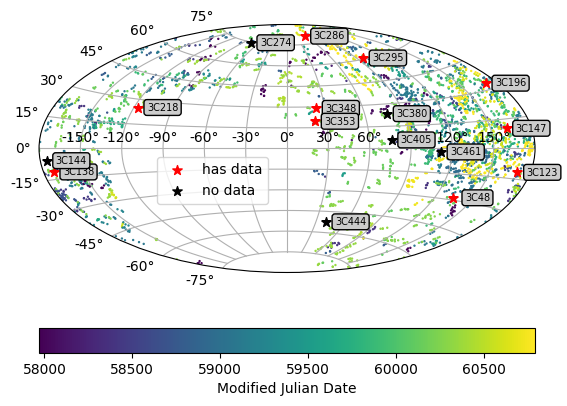

In [12]:
from astropy.coordinates import SkyCoord

gal = SkyCoord(cband_info['l'], cband_info['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
colors = cband_info['time'].apply(lambda l: float(l.split('_')[0])) # color by MJD
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=colors, s=0.5, vmin=min(colors), vmax=max(colors), zorder=1)
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Modified Julian Date')

cal_coords = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_coords_all.csv')
for target, l, b in zip(cal_coords['target'], cal_coords['l'], cal_coords['b']):
    cal_gal = SkyCoord(l, b, unit='deg', frame='galactic')
    color = 'r' if target in good_targs else 'k'
    label = 'has data' if target in good_targs else 'no data'
    ax.scatter(cal_gal.l.wrap_at('180d').radian, cal_gal.b.radian, s=50, c=color, marker='*', zorder=2, label=label)
    x, y = ax.transData.transform((np.radians(cal_gal.l.wrap_at('180d').deg), cal_gal.b.radian))
    x, y = ax.transAxes.inverted().transform((x, y))
    t = ax.text(x+0.05, y, target, fontsize=7, ha='center', va='center', transform=ax.transAxes)
    t.set_bbox(dict(boxstyle='round', fc='0.8'))

#fig.suptitle('Aitoff Projection of C-band Targets with Calibrators')
handles, labels = ax.get_legend_handles_labels()
unique_handles, unique_labels = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

plt.legend(unique_handles, unique_labels, bbox_to_anchor=(0.35, 0.25))
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/mercator_with_calibrators.png', dpi=300)

## Splicing

In [13]:
def get_time_seconds(l):
    return l.split('_')[-3]

def group_by_seconds(files):
    return groupby(sorted(files, key=get_time_seconds), key=get_time_seconds)

def group_by_cadence(files):
    seconds_group = {key: list(group) for key, group in group_by_seconds(files)}

    keys, values = list(seconds_group.keys()), list(seconds_group.values())

    cadences = []
    current_cadence = {keys[0]: values[0]}
    for i in range(len(keys)-1):
        diff = int(keys[i+1]) - int(keys[i])
        if 100 < diff < 140:
            current_cadence[keys[i+1]] = values[i+1]
        else:
            cadences.append(current_cadence)
            current_cadence = {keys[i+1]: values[i+1]}
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    if len(cadences) == 1:
        return cadences[0]
    return cadences

def group_by_target(epochs):
    return {
        epoch: group_by_cadence(files) for epoch, files in epochs.items()
        if len(group_by_cadence(files)) > 0
    }
# new_group = {
#     target: {
#         epoch: {key: list(group) for key, group in group_by_seconds(files)}
#         for epoch, files in epochs.items()
#         if len([k for k, _ in group_by_seconds(files)]) > 3
#     }
#     for target, epochs in groups.items()
# }
new_group = {
    target: group_by_target(epochs) for target, epochs in groups.items()
    if len(group_by_target(epochs)) > 0
}
new_group

{'3C123': {'AGBT20A_999_20_58955': {'57320': ['/datag/pipeline/AGBT20A_999_20/blc04_blp04/blc04_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc32_blp32/blc32_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc07_blp07/blc07_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc26_blp26/blc26_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc00_blp00/blc00_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc17_blp17/blc17_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc13_blp13/blc13_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc20_blp20/blc20_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc34_blp34/blc34_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc15_blp15/b

In [14]:
num_cadences = {target: sum(len(cadences) if isinstance(cadences, list) else 1 for cadences in epochs.values()) for target, epochs in new_group.items()}
num_cadences

{'3C123': 5,
 '3C147': 14,
 '3C196': 9,
 '3C286': 8,
 '3C295': 12,
 '3C353': 2,
 '3C48': 2}

### New sorting

In [9]:
def get_mjd_and_time_seconds(l):
    return '_'.join(l.split('_')[-4:-2])

def get_time_seconds(l):
    return l.split('_')[-3]

def group_by_mjd_and_time_seconds(files):
    return groupby(sorted(files, key=get_mjd_and_time_seconds), key=get_mjd_and_time_seconds)

In [16]:
sorted_by_mjd = sorted(locs2, key=get_mjd_and_time_seconds)
sorted_by_mjd

['/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc04/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc15/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc15/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc16/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc16/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc07/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc07/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc01/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc01/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc05/guppi_57798_56538_3C48_0008.0002.h5',
 '/datag/pipeline/AGBT17A_999_05/blc05/guppi_57798_56538_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17A_99

In [17]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    #files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    # Create dictionary to store cadences and corresponding files
    cadences_dict = {
        cadence[0]: {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadence[0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadence[1]],
        }
        for cadence in cadences
    }
    return cadences_dict

locs_sorted_by_target = {
    target: list(files)
    for target, files in groupby(sorted(locs, key=get_target), key=get_target)
    if target in perley_targs
}
locs_sorted_by_target

{'3C123': ['/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70047_3C123_0104.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_70353_3C123_0105.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72074_3C123_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72214_3C123_0116.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc00/blc00_guppi_59383_72343_3C123_0117.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_70047_3C123_0104.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_70353_3C123_0105.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72074_3C123_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72214_3C123_0116.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc13/blc13_guppi_59383_72343_3C123_0117.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_44/blc24/blc24_guppi_59383_700

In [ ]:
cadence_group = {
    target: group_by_cadence(files)
    for target, files in locs_sorted_by_target.items()
    if len(group_by_cadence(files))
}

cadence_group

{'3C123': {'58955_57320': {'ON': ['/datag/pipeline/AGBT20A_999_20/blc04_blp04/blc04_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc32_blp32/blc32_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc07_blp07/blc07_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc26_blp26/blc26_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc00_blp00/blc00_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc17_blp17/blc17_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc13_blp13/blc13_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc20_blp20/blc20_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc34_blp34/blc34_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_20/blc15_blp15/blc15_guppi_5

In [19]:
num_cadences = {target: len(cadences) for target, cadences in cadence_group.items()}
num_cadences

{'3C123': 5,
 '3C147': 14,
 '3C196': 9,
 '3C286': 8,
 '3C295': 12,
 '3C353': 2,
 '3C48': 2}

In [20]:
sum(num_cadences.values())

52

### Splicing for real

In [17]:
# The 3C353 coefficients are not valid over C-band (valid range is 0.2-4 GHz)
del cadence_group['3C353']

In [18]:
list(cadence_group.keys())

['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']

{'3C123': 5,
 '3C147': 14,
 '3C196': 9,
 '3C286': 8,
 '3C295': 12,
 '3C353': 2,
 '3C48': 2}

In [75]:
perley_coeffs = {
    '3C123': [1.8017, -0.7884, -0.1035, -0.0248, 0.0090],
    '3C147': [1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289],
    '3C196': [1.2872, -0.8530, -0.1534, -0.0200, 0.0201],
    '3C286': [1.2481, -0.4507, -0.1798, 0.0357],
    '3C295': [1.4701, -0.7658, -0.2780, -0.0347, 0.0399],
    '3C48': [1.3253, -0.7553, -0.1914, 0.0498]
}
def flux_jy(freqs, target):
    model = np.poly1d(perley_coeffs[target][::-1])
    return 10**model(np.log10(freqs/1e3)) # convert MHz to GHz

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule

def calculate_sefd(spec, target, eta=0.7, r=50, Tsky=2.728):
    freqs, powers = spec
    s_cal = flux_jy(freqs, target)
    a_eff = eta * np.pi * r**2
    sefd = s_cal / powers - 2 * k * JY_PER_J * Tsky / a_eff
    return np.array([freqs, sefd])

In [48]:
from blimpy import Waterfall
from functools import partial
import gc
from multiprocessing import Pool
from tqdm.auto import tqdm

path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/'
rebinned_comb = np.load('/home/dataadmin/GBTData/SharedDataDirectory/rebinned_comb.npy')

ranges = {
    '0': 6144,
    '1': 8192,
    '2': 8192,
    '3': 7168
}

def despike(ys, cell_size=1024):
    for i in range(cell_size//2-1, len(ys), cell_size):
        ys[i] = np.mean([ys[i-1], ys[i+2]])
        ys[i+1] = np.mean([ys[i], ys[i+2]])
    return ys

def rebin(xs, ys, cell_size=16):
    rebin_size=1024//cell_size
    rebinned_spec = []
    for i in range(len(ys)//rebin_size):
        average = np.mean(ys[i*rebin_size:i*rebin_size+rebin_size])
        rebinned_spec.append(average)

    rebinned_freq = []
    for i in range(len(xs)//rebin_size):
        average = np.mean(xs[i*rebin_size:i*rebin_size+rebin_size])
        rebinned_freq.append(average)
    return rebinned_freq, rebinned_spec

def comb(spec):
    num_windows = len(spec) // 16
    reshaped_power = np.reshape(spec, (num_windows, 16))

    new_power = []
    for i in range(len(reshaped_power)):
        p = reshaped_power[i]
        c = rebinned_comb
        new_power.append(p / c)
    
    return np.concatenate(new_power)

def sigma_filter(data_, window_size=15):
    '''Apply a sigma filter to remove residual spikes.'''
    data = data_.copy()
    for i in range(window_size//2, len(data)-window_size//2):
        window_data = data[i-window_size//2:i+window_size//2+1]
        median = np.median(window_data)
        std = np.std(window_data)
        if abs(data[i] - median) > 3 * std:
            data[i] = median
    return data

def save_bank(items, name=None):
    bank, locs = items

    def process(loc):
        wf = Waterfall(loc)
        xs, ys = wf.grab_data()
        xs = xs[::-1]  # reverse the x-axis
        ys = ys[..., ::-1]  # reverse the y-axis
        ys_avg = np.mean(ys, axis=0)
        ys_despiked = despike(ys_avg)
        xs_rebin, ys_rebin = rebin(xs, ys_despiked)
        ys_combed = comb(ys_rebin)
        ys_filt = sigma_filter(ys_combed)
        rebinned = np.array([xs_rebin, ys_filt])
        return rebinned

    specs = list(map(process, locs))
    bank_spec = np.concatenate(specs, axis=1)
    sort_indices = np.argsort(bank_spec[0])
    bank_spec = bank_spec[:, sort_indices]

    # Throw out spectrum if the start frequency is below 3000 MHz
    if bank_spec[0][0] < 3000:
        raise Exception(f"Spectrum falls outside C band.")
    
    # Throw out spectrum if there are frequency gaps between data blocks
    diffs = np.diff(bank_spec[0])
    if max(diffs) > 2 * diffs[0]:
        raise Exception(f"Spliced spectrum has a frequency gap.")
    
    size = len(bank_spec[0])

    # Trim bank 0 and 3 spectra to 6 and 7 nodes respectively (ad hoc)
    if bank == '0' and size == 8192:
        bank_spec = bank_spec[:, 2048:]
    if bank == '3' and size == 8192:
        bank_spec = bank_spec[:, :-1024]
    
    # Throw out spectrum that is the wrong size
    if len(bank_spec[0]) != ranges[bank]:
        raise Exception(f"Spectrum is the wrong size ({len(bank_spec[0])}, expected {ranges[bank]}).")
    
    os.makedirs(os.path.join(path_to_save, bank, name.replace(name.split('/')[-1], '')), exist_ok=True)
    np.save(os.path.join(path_to_save, bank, name), bank_spec)

def splice_banks(name, locs):
    banks = {}
    for loc in locs:
        #bank = loc.split('/')[4][-2]
        bank = loc.split('/')[4][3] # this appears to apply in general for C band. 7/28/26
        if bank not in banks:
            banks[bank] = []
        banks[bank].append(loc)
    
    def rename_keys(keys):
        sorted_keys = sorted(keys, key=int, reverse=True)
        new_keys = [str(sorted_keys.index(key)) for key in keys]
        return new_keys
    
    keys = list(banks.keys())
    mapping = dict(zip(keys, rename_keys(keys)))
    banks = {mapping[k]: v for k, v in banks.items()}
        
    # for bank in banks.keys():
    #     new_bank = 3 - int(bank)
    #     new_bank = str(new_bank)
    #     banks_copy[new_bank] = banks[bank]
    # banks = banks_copy

    good_banks = []
    def save_bank_wrapper(items):
        try:
            save_bank(items, name=name)
            good_banks.append(items[0])
        except Exception as e:
            print(f'Something went wrong: {e}\nSkipping bank {items[0]} for {name}.')
    
    _ = list(map(save_bank_wrapper, banks.items()))
    gc.collect()
    return good_banks

def save_cadence(items, target=None):
    time, cadence_dict = items

    name_on = f'{target}/{time}/ON.npy'
    banks_on = splice_banks(name_on, cadence_dict['ON'])
    name_off = f'{target}/{time}/OFF.npy'
    banks_off = splice_banks(name_off, cadence_dict['OFF'])
    
    banks = set(banks_on).intersection(set(banks_off))

    for bank in banks:
        bank_path = os.path.join(path_to_save, bank)
        spec_on = np.load(os.path.join(bank_path, name_on))
        spec_off = np.load(os.path.join(bank_path, name_off))
        spec_diff = np.array([spec_on[0], (spec_on[1] - spec_off[1]) / spec_off[1]])
        np.save(os.path.join(bank_path, f'{target}/{time}/ON_OFF.npy'), spec_diff)

        sefd = calculate_sefd(spec_diff, target)
        np.save(os.path.join(bank_path, f'{target}/{time}/SEFD.npy'), sefd)


def save_target(items):
    target, target_dict = items
    save_cadence_partial = partial(save_cadence, target=target)
    _ = list(tqdm(map(save_cadence_partial, target_dict.items()), total=len(target_dict), desc=f'Saving target {target}'))

_ = list(map(save_target, cadence_group.items()))

Saving target 3C123:   0%|          | 0/5 [00:00<?, ?it/s]

Saving target 3C147:   0%|          | 0/14 [00:00<?, ?it/s]

Saving target 3C196:   0%|          | 0/9 [00:00<?, ?it/s]

Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 2 for 3C196/60161_38854/ON.npy.
Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 2 for 3C196/60161_38854/OFF.npy.


Saving target 3C286:   0%|          | 0/8 [00:00<?, ?it/s]

Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 3 for 3C286/59532_55134/ON.npy.
Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 3 for 3C286/59532_55134/OFF.npy.


Saving target 3C295:   0%|          | 0/12 [00:00<?, ?it/s]

Saving target 3C48:   0%|          | 0/2 [00:00<?, ?it/s]

In [38]:
cadence_group['3C196']['59329_57801']

{'ON': ['/datag/pipeline/AGBT21A_996_29/blc53/blc53_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc75/blc75_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc50/blc50_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc63/blc63_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc55/blc55_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc57/blc57_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc76/blc76_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc71/blc71_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc56/blc56_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc51/blc51_guppi_59329_57801_3C196_0016.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_29/blc65/blc65_guppi_59329_57801_

In [33]:
cadence_group['3C295']['59348_41294']

{'ON': ['/datag/pipeline/AGBT21A_996_36/blc45/blc45_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc40/blc40_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc46/blc46_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc44/blc44_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc57/blc57_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc66/blc66_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc55/blc55_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc41/blc41_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc67/blc67_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc54/blc54_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc62/blc62_guppi_59348_41294_

# Plots

In [54]:
%matplotlib inline

## Test

In [19]:
cadence = random.choice(list(cadence_group["3C48"].keys()))
cadence

'60132_27332'

Text(0.5, 1.0, '3C48: 60132_27332')

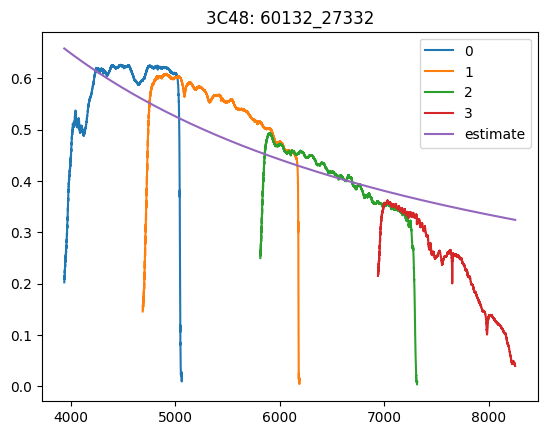

In [27]:
targ = '3C48'
for bank in range(4):
    data = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/{bank}/{targ}/{cadence}/ON_OFF.npy')
    plt.plot(*data, label=str(bank))
    if bank == 0:
        xmin = data[0][0]
    if bank == 3:
        xmax = data[0][-1]
# Overlay flux model
xs = np.linspace(xmin, xmax, 1000)
plt.plot(xs, flux_jy(xs, targ)/10, label='estimate') # C-band estimated SEFD is 10
plt.legend()
plt.title(f'{targ}: {cadence}')

Text(0, 0.5, 'Number of Cadences')

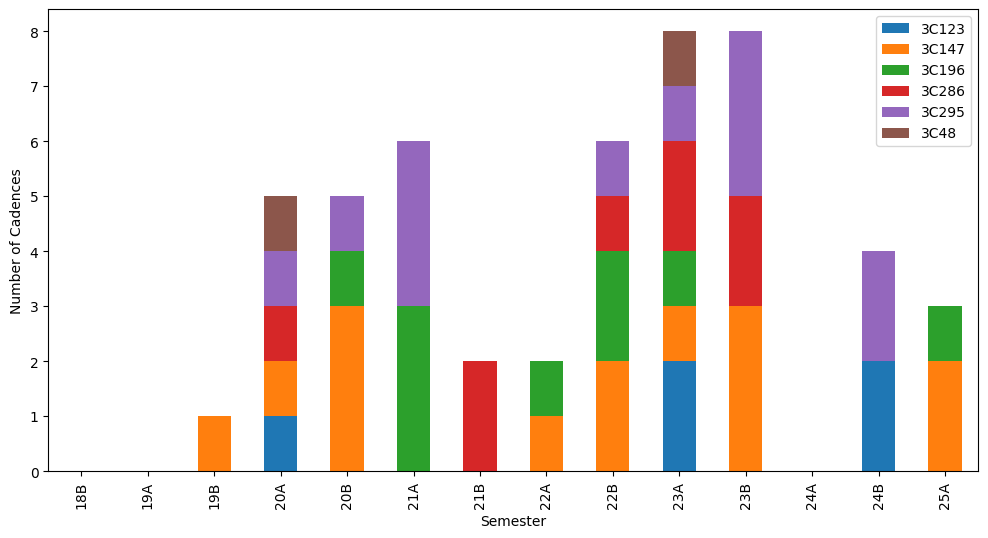

In [28]:
# Semester plot of the cadences
all_semesters = ['18B', '19A', '19B', '20A',
                 '20B', '21A', '21B', '22A',
                 '22B', '23A', '23B', '24A',
                 '24B', '25A']
# For each target, get the number of cadences in each semester
semester_counts = {
    target: [
        [cadence['ON'][0].split('/')[3][4:7] for cadence in cadences.values()].count(sem)
        for sem in all_semesters
    ]
    for target, cadences in cadence_group.items()
}
# Turn into a DataFrame for easier plotting
semester_df = pd.DataFrame(semester_counts, index=all_semesters)
semester_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Semester')
plt.ylabel('Number of Cadences')

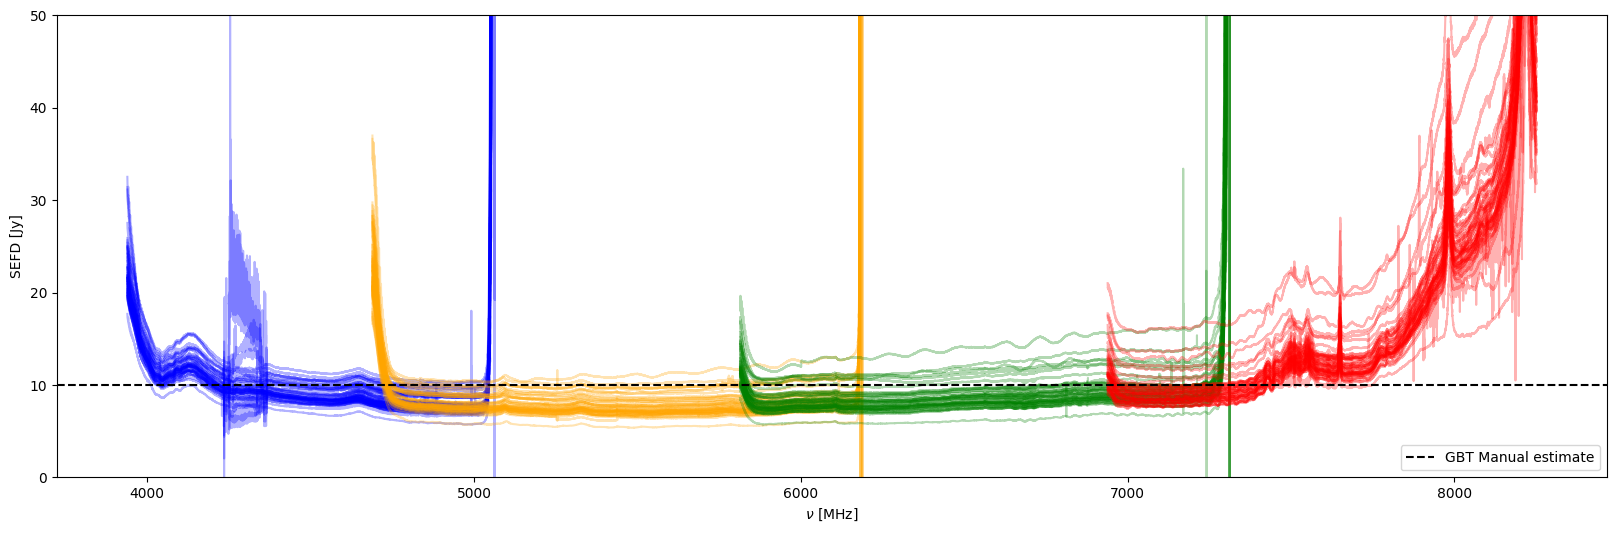

In [ ]:
# Plot SEFDs by bank
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/'

all_sefd = []
times = []

fig, ax = plt.subplots(figsize=(20, 6))

colors = ['blue', 'orange', 'green', 'red']
for bank, color in enumerate(colors):
    for target in targets:
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                ax.plot(sefd[0], sefd[1], alpha=0.3, color=color)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
        
ax.axhline(10, color='k', linestyle='--', label='GBT Manual estimate')
ax.set_ylim(0, 50)
ax.set_xlabel('$\\nu$ [MHz]')
ax.set_ylabel('SEFD [Jy]')
ax.legend()

In [38]:
from collections import Counter

for bank in range(4):
    path = os.path.join(calibration_path, str(bank))
    lens = [
        len(np.load(os.path.join(path, targ, cadence, 'SEFD.npy'))[0])
        for targ in os.listdir(path)
        for cadence in os.listdir(os.path.join(path, targ)) 
    ]
    counts = dict(Counter(lens))
    print(f'{bank} lengths: {counts}')

0 lengths: {6144: 50}
1 lengths: {8192: 50}
2 lengths: {8192: 48}
3 lengths: {7168: 47}


Text(0, 0.5, 'SEFD [Jy]')

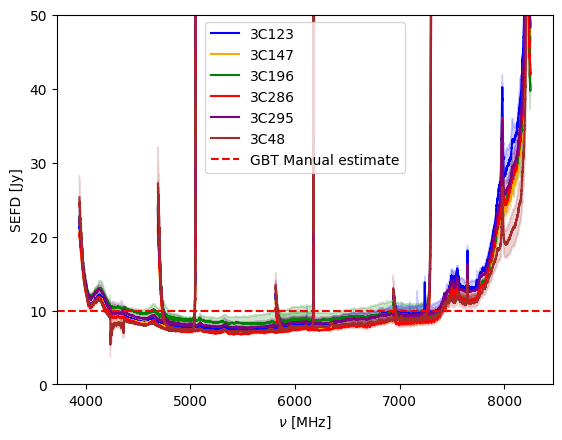

In [45]:
# Average SEFD of all targets
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black', 'teal', 'navy', 'maroon']
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48'] #os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/0/')
for target, color in zip(targets, colors):
    for bank in range(4):
        calibration_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/{bank}/{target}'
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        all_sefd = []
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)[1]
                all_sefd.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
        median = np.median(all_sefd, axis=0)
        q1 = np.percentile(all_sefd, 25, axis=0)
        q3 = np.percentile(all_sefd, 75, axis=0)
        label = target if bank == 0 else None
        plt.plot(np.load(path)[0], median, label=label, color=color)
        plt.fill_between(np.load(path)[0], q1, q3, color=color, alpha=0.2)
        # for sefd in all_sefd:
        #     plt.plot(np.load(path)[0], sefd, color=color, alpha=0.1)
plt.axhline(10, color='r', linestyle='--', label='GBT Manual estimate')
plt.legend()
plt.ylim(0,50)
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('SEFD [Jy]')

# Saving the median SEFDs

In [3]:
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/'
med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/median_sefds/'


for bank in range(4):
    all_sefd = []

    os.makedirs(os.path.join(med_sefd_path, str(bank)), exist_ok=True)

    for target in targets:
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                all_sefd.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
            
    median = np.median(all_sefd, axis=0)
    p_16 = np.percentile(all_sefd, 16, axis=0)
    p_84 = np.percentile(all_sefd, 84, axis=0)
    np.save(os.path.join(med_sefd_path, str(bank), 'median.npy'), median)
    np.save(os.path.join(med_sefd_path, str(bank), '16th.npy'), p_16)
    np.save(os.path.join(med_sefd_path, str(bank), '84th.npy'), p_84)

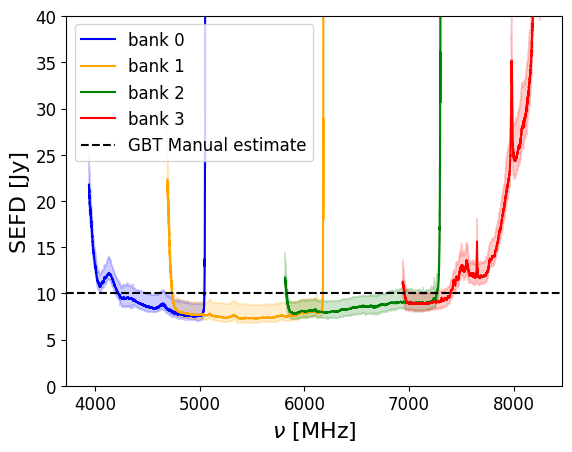

In [ ]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 12})

colors = ['blue', 'orange', 'green', 'red']

for bank, color in enumerate(colors):
    path = os.path.join(med_sefd_path, str(bank))
    if os.path.exists(path):
        median = np.load(os.path.join(path, 'median.npy'))
        p_16 = np.load(os.path.join(path, '16th.npy'))
        p_84 = np.load(os.path.join(path, '84th.npy'))
        plt.plot(median[0], median[1], color=color, label=f'bank {bank}')
        plt.fill_between(median[0], p_16[1], p_84[1], color=color, alpha=0.2)

plt.ylim(0,40)
plt.axhline(10, color='k', linestyle='--', label='GBT Manual estimate')
plt.legend()
plt.xlabel('$\\nu$ [MHz]', fontsize=16)
plt.ylabel('SEFD [Jy]', fontsize=16)
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/median_sefds.png', dpi=300, bbox_inches='tight')

In [56]:
p_16_all = np.concatenate([np.load(os.path.join(med_sefd_path, str(bank), '16th.npy'))[1] for bank in range(4)])
p_84_all = np.concatenate([np.load(os.path.join(med_sefd_path, str(bank), '84th.npy'))[1] for bank in range(4)])
np.mean(p_84_all - p_16_all) # average spread

3.0454492964506463

3 Jy spread.

## 07/14/26: Oopsie poopsie, need to add back sky temp

1.369511005626224
26.470519173262296


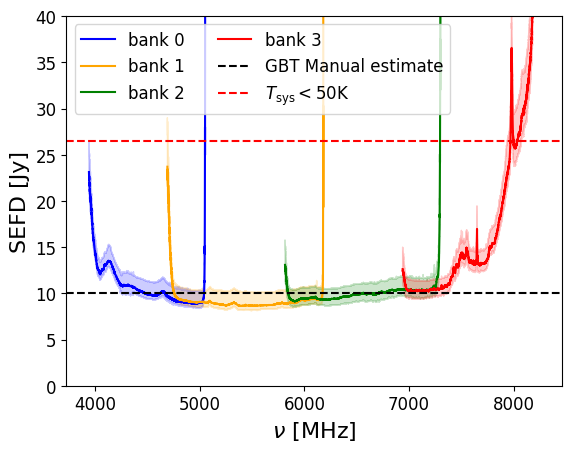

In [12]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 12})

targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans/'
med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/median_sefds/'

colors = ['blue', 'orange', 'green', 'red']

fig, ax = plt.subplots()

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule
Tsky = 2.728
eta = 0.7
r = 50
a_eff = eta * np.pi * r**2

SEFD_sky = 2 * k * JY_PER_J * Tsky / a_eff
print(SEFD_sky)

SEFD_max = 2 * k * JY_PER_J * (50+Tsky) / a_eff # Tsys<50 K metric
print(SEFD_max)

for bank, color in enumerate(colors):
    path = os.path.join(med_sefd_path, str(bank))
    if os.path.exists(path):
        median = np.load(os.path.join(path, 'median.npy'))
        p_16 = np.load(os.path.join(path, '16th.npy'))
        p_84 = np.load(os.path.join(path, '84th.npy'))
        ax.plot(median[0], median[1] + SEFD_sky, color=color, label=f'bank {bank}')
        ax.fill_between(median[0], p_16[1] + SEFD_sky, p_84[1] + SEFD_sky, color=color, alpha=0.2)

ax.set_ylim(0,40)
ax.axhline(10, color='k', linestyle='--', label='GBT Manual estimate')
ax.axhline(SEFD_max, color='r', linestyle='--', label=r'$T_\mathrm{sys} < 50 \mathrm{K}$')
ax.legend(loc='upper left', ncol=2)
ax.set_xlabel('$\\nu$ [MHz]', fontsize=16)
ax.set_ylabel('SEFD [Jy]', fontsize=16)
fig.savefig('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/median_sefds_corrected_071426.png', dpi=300, bbox_inches='tight')

### Correct SEFDs

In [2]:
med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/median_sefds/'

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule
Tsky = 2.728
eta = 0.7
r = 50
a_eff = eta * np.pi * r**2

SEFD_sky = 2 * k * JY_PER_J * Tsky / a_eff
print(SEFD_sky)

for bank in range(4):
    path = os.path.join(med_sefd_path, str(bank))
    median = np.load(os.path.join(path, 'median.npy'))
    p_16 = np.load(os.path.join(path, '16th.npy'))
    p_84 = np.load(os.path.join(path, '84th.npy'))
    np.save(os.path.join(path, 'median.npy'), np.array([median[0], median[1] + SEFD_sky]))
    np.save(os.path.join(path, '16th.npy'), np.array([p_16[0], p_16[1] + SEFD_sky]))
    np.save(os.path.join(path, '84th.npy'), np.array([p_84[0], p_84[1] + SEFD_sky]))

1.369511005626224


## X band new plot

In [6]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

1.369511005626224
26.470519173262296
SEFD shape mismatch for 0/3C196/59525_56816, skipping
(2, 6144)
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(2, 4096)
SEFD shape mismatch for 1/3C48/59572_22577, skipping
(2, 7168)
No data for 3C48 in bank 3, skipping


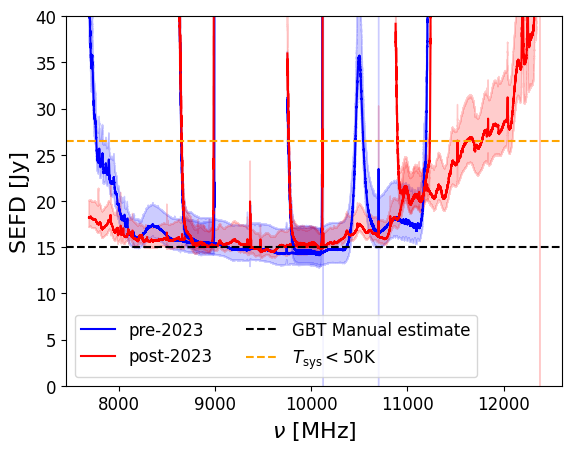

In [11]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 12})

targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'
#med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/median_sefds/'

colors = ['blue', 'orange', 'green', 'red']

fig, ax = plt.subplots()

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule
Tsky = 2.728
eta = 0.7
r = 50
a_eff = eta * np.pi * r**2

SEFD_sky = 2 * k * JY_PER_J * Tsky / a_eff
print(SEFD_sky)

SEFD_max = 2 * k * JY_PER_J * (50+Tsky) / a_eff # Tsys<50 K metric
print(SEFD_max)

for bank in range(4):
    pre22B = []
    post22B = []
    shape = 7168 if bank == 0 else 8192
    for target in targets:
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                if sefd.shape[1] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                time = convert_to_seconds(cadence)
                if time < 5.18e9:
                    pre22B.append(sefd)
                else:
                    post22B.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
    if pre22B:
        pre22B_median = np.median(pre22B, axis=0)
        pre22B_16 = np.percentile(pre22B, 16, axis=0)
        pre22B_84 = np.percentile(pre22B, 84, axis=0)
        ax.plot(pre22B_median[0], pre22B_median[1] + SEFD_sky, color='b', label=f'pre-2023' if bank == 0 else None)
        ax.fill_between(pre22B_median[0], pre22B_16[1] + SEFD_sky, pre22B_84[1] + SEFD_sky, color='b', alpha=0.2)
    if post22B:
        post22B_median = np.median(post22B, axis=0)
        post22B_16 = np.percentile(post22B, 16, axis=0)
        post22B_84 = np.percentile(post22B, 84, axis=0)
        ax.plot(post22B_median[0], post22B_median[1] + SEFD_sky, color='r', label=f'post-2023' if bank == 0 else None)
        ax.fill_between(post22B_median[0], post22B_16[1] + SEFD_sky, post22B_84[1] + SEFD_sky, color='r', alpha=0.2)

ax.set_ylim(0,40)
ax.axhline(15, color='k', linestyle='--', label='GBT Manual estimate')
ax.axhline(SEFD_max, color='orange', linestyle='--', label=r'$T_\mathrm{sys} < 50 \mathrm{K}$')
ax.legend(loc='lower left', ncol=2)
ax.set_xlabel('$\\nu$ [MHz]', fontsize=16)
ax.set_ylabel('SEFD [Jy]', fontsize=16)
fig.savefig('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/median_sefds_corrected_071426.png', dpi=300, bbox_inches='tight')

# Second try

## Sorting

### >=2 scans

In [10]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    #files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 2]
    # Create dictionary to store cadences and corresponding files
    cadences_dict = {
        cadence[0]: {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadence[0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadence[1]],
        }
        for cadence in cadences
    }
    return cadences_dict

locs_sorted_by_target = {
    target: list(files)
    for target, files in groupby(sorted(locs, key=get_target), key=get_target)
    if target in perley_targs
}

cadence_group = {
    target: group_by_cadence(files)
    for target, files in locs_sorted_by_target.items()
    if len(group_by_cadence(files))
}

cadence_group

{'3C123': {'58656_74012': {'ON': ['/datag/pipeline/AGBT19A_999_57/blp03/blc03_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp33/blc33_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp12/blc12_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp02/blc02_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp01/blc01_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp16/blc16_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp10/blc10_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp21/blc21_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp25/blc25_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_57/blp06/blc06_guppi_58656_74012_3C123_0111.gpuspec.0002.h5',
    '/datag/pipeline

In [11]:
num_cadences = {target: len(cadences) for target, cadences in cadence_group.items()}
sum(num_cadences.values())

169

### >=2 scans and save session name (one "triplet" per session)

In [15]:
def get_epoch(l):
    return l.split('/')[3]

def epoch_sort_key(l):
    return l.split('/')[3], convert_to_seconds('_'.join(l.split('_')[-4:-2]))

epochs = list(set(cband_info['epoch']))

calibrator_locs = [loc for loc in locs if get_target(loc) in perley_targs and get_epoch(loc) in epochs]
calibrator_locs

['/datag/pipeline/AGBT18B_999_67/blp00/blc30_guppi_58447_34341_3C196_0092.gpuspec.0002.h5',
 '/datag/pipeline/AGBT18B_999_67/blp33/blc63_guppi_58447_34341_3C196_0092.gpuspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc30_blp30/blc30_guppi_59132_46804_3C295_0113.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc30_blp30/blc30_guppi_59132_46944_3C295_0114.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc16_blp16/blc16_guppi_59132_46804_3C295_0113.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc30_blp30/blc30_guppi_59132_47073_3C295_0115.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc16_blp16/blc16_guppi_59132_46944_3C295_0114.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc16_blp16/blc16_guppi_59132_47073_3C295_0115.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25/blc22_blp22/blc22_guppi_59132_15826_3C147_0012.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_04/blc36_blp26/blc36_guppi_59075_28769_3C147_0008.rawspec.0002.h5',
 '/datag/pipeline/AGBT20B_999_25

In [16]:
calibrator_locs_sorted = {epoch: list(files) for epoch, files in groupby(sorted(calibrator_locs, key=epoch_sort_key), key=get_epoch)}
calibrator_locs_sorted

{'AGBT17B_999_11': ['/datag/pipeline/AGBT17B_999_11/blc18_blp17/blc17_guppi_57985_37651_3C138_0006.gpuspec.0002.h5'],
 'AGBT17B_999_21': ['/datag/pipeline/AGBT17B_999_21/blc18_blp17/blc17_guppi_57999_78351_3C348_0006.gpuspec.0002.h5'],
 'AGBT18B_999_19': ['/datag/pipeline/AGBT18B_999_19/blc40_blp30/blc40_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc43_blp33/blc43_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc62_blp12/blc62_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc64_blp14/blc64_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc77_blp27/blc77_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc70_blp20/blc70_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc76_blp26/blc76_guppi_58369_23595_3C48_0007.gpuspec.0002.h5',
  '/datag/pipeline/AGBT18B_999_19/blc60_blp10/blc60_guppi_58

In [17]:
len(calibrator_locs_sorted)

92

In [18]:
def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    #files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 2]
    # Create dictionary to store cadences and corresponding files
    cadences_dict = {
        cadence[0]: {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadence[0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadence[1]],
        }
        for cadence in cadences
    }
    return cadences_dict

cadence_group = {
    epoch: group_by_cadence(files)
    for epoch, files in calibrator_locs_sorted.items()
    if len(group_by_cadence(files))
}

cadence_group

{'AGBT19A_999_44': {'58617_71227': {'ON': ['/datag/pipeline/AGBT19A_999_44/blp13/blc53_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp16/blc56_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp03/blc43_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp04/blc44_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp14/blc54_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp27/blc67_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp17/blc57_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp02/blc42_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp21/blc61_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19A_999_44/blp15/blc55_guppi_58617_71227_3C295_0066.gpuspec.0002.h5',
    '/datag

In [19]:
num_cadences = {target: len(cadences) for target, cadences in cadence_group.items()}

In [20]:
len(cadence_group)

80

In [21]:
sum(num_cadences.values())

140

(array([43., 21., 12.,  2.,  1.,  1.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

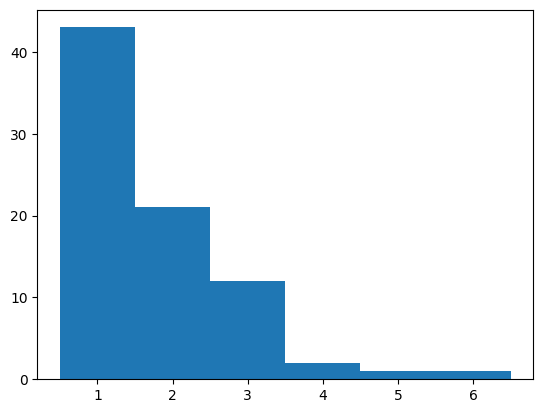

In [22]:
plt.hist(num_cadences.values(), bins=np.arange(0.5, max(num_cadences.values())+1, 1))

### >=3 scans and save session name

In [23]:
def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    #files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    # Create dictionary to store cadences and corresponding files
    cadences_dict = {
        cadence[0]: {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadence[0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadence[1]],
        }
        for cadence in cadences
    }
    return cadences_dict

cadence_group = {
    epoch: group_by_cadence(files)
    for epoch, files in calibrator_locs_sorted.items()
    if len(group_by_cadence(files))
}

cadence_group

{'AGBT19B_999_107': {'58799_80359': {'ON': ['/datag/pipeline/AGBT19B_999_107/blc42_blp02/blc42_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc67_blp27/blc67_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc50_blp10/blc50_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc45_blp05/blc45_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc57_blp17/blc57_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc60_blp20/blc60_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc75_blp35/blc75_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc63_blp23/blc63_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc53_blp13/blc53_guppi_58799_80359_3C353_0097.gpuspec.0002.h5',
    '/datag/pipeline/AGBT19B_999_107/blc74

(array([31.,  6.]), array([0.5, 1.5, 2.5]), <BarContainer object of 2 artists>)

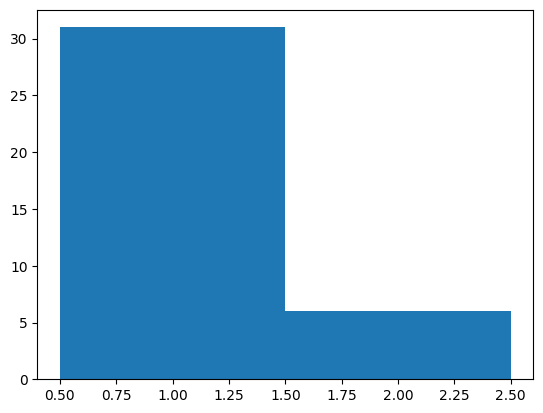

In [24]:
num_cadences = {target: len(cadences) for target, cadences in cadence_group.items()}
plt.hist(num_cadences.values(), bins=np.arange(0.5, max(num_cadences.values())+1, 1))

**For now, just pick the first cadence in each epoch. If the normalized gain method stands a chance, then I'll investigate the scans further...**

In [25]:
good_targs = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']

def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    #files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]

    # Create dictionary to store FIRST CADENCE and corresponding files
    if len(cadences):
        # Lists of on and off files
        on = [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][0]]
        off = [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][1]]
        # Don't save 3C353 scans
        targ = on[0].split('_')[-2]
        if targ not in good_targs:
            print(f'{targ} is bad!!!!!! Skipping epoch {files[0].split("/")[3]} :)')
            return None
        
        cadences_dict = {
            'ON': on,
            'OFF': off,
        }
        
        return cadences_dict
    else:
        return None


cadence_group = {
    epoch: group_by_cadence(files)
    for epoch, files in calibrator_locs_sorted.items()
    if group_by_cadence(files)
}

cadence_group

3C353 is bad!!!!!! Skipping epoch AGBT19B_999_107 :)


{'AGBT20A_999_20': {'ON': ['/datag/pipeline/AGBT20A_999_20/blc04_blp04/blc04_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc32_blp32/blc32_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc07_blp07/blc07_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc26_blp26/blc26_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc00_blp00/blc00_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc17_blp17/blc17_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc13_blp13/blc13_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc20_blp20/blc20_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc34_blp34/blc34_guppi_58955_57320_3C123_0038.rawspec.0002.h5',
   '/datag/pipeline/AGBT20A_999_20/blc15_blp15/blc15_guppi_58955_57320_3C123

In [26]:
len(cadence_group)

36

## Calibrator lookup

In [69]:
cal_lookup = {
    epoch: epoch_dict['ON'][0].split('_')[-2]
    for epoch, epoch_dict in cadence_group.items()
}
cal_lookup

{'AGBT20A_999_20': '3C123',
 'AGBT20A_999_38': '3C147',
 'AGBT20A_999_44': '3C295',
 'AGBT20A_999_46': '3C286',
 'AGBT20A_999_47': '3C48',
 'AGBT20B_999_04': '3C147',
 'AGBT20B_999_09': '3C147',
 'AGBT20B_999_25': '3C147',
 'AGBT20B_999_27': '3C196',
 'AGBT20B_999_37': '3C295',
 'AGBT21A_996_18': '3C295',
 'AGBT21B_999_27': '3C286',
 'AGBT22A_999_34': '3C147',
 'AGBT22B_999_16': '3C147',
 'AGBT22B_999_17': '3C196',
 'AGBT22B_999_18': '3C286',
 'AGBT22B_999_29': '3C147',
 'AGBT23A_999_19': '3C147',
 'AGBT23A_999_22': '3C48',
 'AGBT23A_999_23': '3C123',
 'AGBT23A_999_29': '3C295',
 'AGBT23A_999_33': '3C196',
 'AGBT23A_999_40': '3C286',
 'AGBT23A_999_41': '3C286',
 'AGBT23B_999_04': '3C147',
 'AGBT23B_999_07': '3C295',
 'AGBT23B_999_26': '3C295',
 'AGBT23B_999_31': '3C286',
 'AGBT23B_999_32': '3C147',
 'AGBT23B_999_37': '3C295',
 'AGBT23B_999_40': '3C286',
 'AGBT24B_999_06': '3C295',
 'AGBT24B_999_08': '3C295',
 'AGBT24B_999_10': '3C123',
 'AGBT25A_999_11': '3C196',
 'AGBT25A_999_19': '3C

In [ ]:
with open('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/calibrator_lookup.json', 'w') as f:
    json.dump(cal_lookup, f, indent=4)

## Time lookup

In [27]:
time_lookup = {
    epoch: get_mjd_and_time_seconds(epoch_dict['ON'][0])
    for epoch, epoch_dict in cadence_group.items()
}
time_lookup

{'AGBT20A_999_20': '58955_57320',
 'AGBT20A_999_38': '58998_48076',
 'AGBT20A_999_44': '59023_28520',
 'AGBT20A_999_46': '59027_17864',
 'AGBT20A_999_47': '59028_63198',
 'AGBT20B_999_04': '59075_28630',
 'AGBT20B_999_09': '59089_26932',
 'AGBT20B_999_25': '59132_15826',
 'AGBT20B_999_27': '59138_17426',
 'AGBT20B_999_37': '59167_79283',
 'AGBT21A_996_18': '59299_46955',
 'AGBT21B_999_27': '59532_55134',
 'AGBT22A_999_34': '59741_44479',
 'AGBT22B_999_16': '59875_12588',
 'AGBT22B_999_17': '59881_65970',
 'AGBT22B_999_18': '59882_76295',
 'AGBT22B_999_29': '59910_04712',
 'AGBT23A_999_19': '60120_41765',
 'AGBT23A_999_22': '60132_27332',
 'AGBT23A_999_23': '60133_38089',
 'AGBT23A_999_29': '60145_23584',
 'AGBT23A_999_33': '60161_38854',
 'AGBT23A_999_40': '60228_81165',
 'AGBT23A_999_41': '60229_79721',
 'AGBT23B_999_04': '60274_04536',
 'AGBT23B_999_07': '60275_82688',
 'AGBT23B_999_26': '60322_69401',
 'AGBT23B_999_31': '60331_57886',
 'AGBT23B_999_32': '60333_31563',
 'AGBT23B_999_

In [28]:
with open('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/time_lookup.json', 'w') as f:
    json.dump(time_lookup, f, indent=4)

## Splicing

In [71]:
with open('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/calibrator_lookup.json', 'r') as f:
    cal_lookup = json.load(f)

In [76]:
from blimpy import Waterfall
from functools import partial
import gc
from multiprocessing import Pool
from tqdm.auto import tqdm

path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/calibrator_scans_v2/'
rebinned_comb = np.load('/home/dataadmin/GBTData/SharedDataDirectory/rebinned_comb.npy')

ranges = {
    '0': 6144,
    '1': 8192,
    '2': 8192,
    '3': 7168
}

def despike(ys, cell_size=1024):
    for i in range(cell_size//2-1, len(ys), cell_size):
        ys[i] = np.mean([ys[i-1], ys[i+2]])
        ys[i+1] = np.mean([ys[i], ys[i+2]])
    return ys

def rebin(xs, ys, cell_size=16):
    rebin_size=1024//cell_size
    rebinned_spec = []
    for i in range(len(ys)//rebin_size):
        average = np.mean(ys[i*rebin_size:i*rebin_size+rebin_size])
        rebinned_spec.append(average)

    rebinned_freq = []
    for i in range(len(xs)//rebin_size):
        average = np.mean(xs[i*rebin_size:i*rebin_size+rebin_size])
        rebinned_freq.append(average)
    return rebinned_freq, rebinned_spec

def comb(spec):
    num_windows = len(spec) // 16
    reshaped_power = np.reshape(spec, (num_windows, 16))

    new_power = []
    for i in range(len(reshaped_power)):
        p = reshaped_power[i]
        c = rebinned_comb
        new_power.append(p / c)
    
    return np.concatenate(new_power)

def sigma_filter(data_, window_size=15):
    '''Apply a sigma filter to remove residual spikes.'''
    data = data_.copy()
    for i in range(window_size//2, len(data)-window_size//2):
        window_data = data[i-window_size//2:i+window_size//2+1]
        median = np.median(window_data)
        std = np.std(window_data)
        if abs(data[i] - median) > 3 * std:
            data[i] = median
    return data

def save_bank(items, name=None):
    bank, locs = items

    def process(loc):
        wf = Waterfall(loc)
        xs, ys = wf.grab_data()
        xs = xs[::-1]  # reverse the x-axis
        ys = ys[..., ::-1]  # reverse the y-axis
        ys_avg = np.mean(ys, axis=0)
        ys_despiked = despike(ys_avg)
        xs_rebin, ys_rebin = rebin(xs, ys_despiked)
        ys_combed = comb(ys_rebin)
        ys_filt = sigma_filter(ys_combed)
        rebinned = np.array([xs_rebin, ys_filt])
        return rebinned

    specs = list(map(process, locs))
    bank_spec = np.concatenate(specs, axis=1)
    sort_indices = np.argsort(bank_spec[0])
    bank_spec = bank_spec[:, sort_indices]

    # Throw out spectrum if the start frequency is below 3000 MHz
    if bank_spec[0][0] < 3000:
        raise Exception(f"Spectrum falls outside C band.")
    
    # Throw out spectrum if there are frequency gaps between data blocks
    diffs = np.diff(bank_spec[0])
    if max(diffs) > 2 * diffs[0]:
        raise Exception(f"Spliced spectrum has a frequency gap.")
    
    size = len(bank_spec[0])

    # Trim bank 0 and 3 spectra to 6 and 7 nodes respectively (ad hoc)
    if bank == '0' and size == 8192:
        bank_spec = bank_spec[:, 2048:]
    if bank == '3' and size == 8192:
        bank_spec = bank_spec[:, :-1024]
    
    # Throw out spectrum that is the wrong size
    if len(bank_spec[0]) != ranges[bank]:
        raise Exception(f"Spectrum is the wrong size ({len(bank_spec[0])}, expected {ranges[bank]}).")
    
    os.makedirs(os.path.join(path_to_save, bank, name.replace(name.split('/')[-1], '')), exist_ok=True)
    np.save(os.path.join(path_to_save, bank, name), bank_spec)

def splice_banks(name, locs):
    banks = {}
    for loc in locs:
        #bank = loc.split('/')[4][-2]
        bank = loc.split('/')[4][3] # this appears to apply in general for C band. 7/28/26
        if bank not in banks:
            banks[bank] = []
        banks[bank].append(loc)
    
    def rename_keys(keys):
        sorted_keys = sorted(keys, key=int, reverse=True)
        new_keys = [str(sorted_keys.index(key)) for key in keys]
        return new_keys
    
    keys = list(banks.keys())
    mapping = dict(zip(keys, rename_keys(keys)))
    banks = {mapping[k]: v for k, v in banks.items()}
        
    # for bank in banks.keys():
    #     new_bank = 3 - int(bank)
    #     new_bank = str(new_bank)
    #     banks_copy[new_bank] = banks[bank]
    # banks = banks_copy

    good_banks = []
    def save_bank_wrapper(items):
        try:
            save_bank(items, name=name)
            good_banks.append(items[0])
        except Exception as e:
            print(f'Something went wrong: {e}\nSkipping bank {items[0]} for {name}.')
    
    _ = list(map(save_bank_wrapper, banks.items()))
    gc.collect()
    return good_banks

def save_cadence(items):
    epoch, cadence_dict = items

    target = cal_lookup[epoch]

    name_on = f'{epoch}/ON.npy'
    banks_on = splice_banks(name_on, cadence_dict['ON'])
    name_off = f'{epoch}/OFF.npy'
    banks_off = splice_banks(name_off, cadence_dict['OFF'])
    
    banks = set(banks_on).intersection(set(banks_off))

    for bank in banks:
        bank_path = os.path.join(path_to_save, bank)
        spec_on = np.load(os.path.join(bank_path, name_on))
        spec_off = np.load(os.path.join(bank_path, name_off))
        spec_diff = np.array([spec_on[0], (spec_on[1] - spec_off[1]) / spec_off[1]])
        np.save(os.path.join(bank_path, epoch, 'ON_OFF.npy'), spec_diff)

        gain = (spec_on[1] - spec_off[1]) / flux_jy(spec_on[0], target)
        spec_gain = np.array([spec_on[0], gain])
        np.save(os.path.join(bank_path, epoch, 'gain.npy'), spec_gain)

        sefd = calculate_sefd(spec_diff, target)
        np.save(os.path.join(bank_path, epoch, 'SEFD.npy'), sefd)

_ = list(tqdm(map(save_cadence, cadence_group.items()), total=len(cadence_group)))

  0%|          | 0/36 [00:00<?, ?it/s]

Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 3 for AGBT21B_999_27/ON.npy.
Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 3 for AGBT21B_999_27/OFF.npy.
Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 2 for AGBT23A_999_33/ON.npy.
Something went wrong: Spliced spectrum has a frequency gap.
Skipping bank 2 for AGBT23A_999_33/OFF.npy.


In [77]:
[len(os.listdir(os.path.join(path_to_save, str(bank)))) for bank in range(4)]

[36, 36, 35, 35]

In [82]:
%matplotlib inline

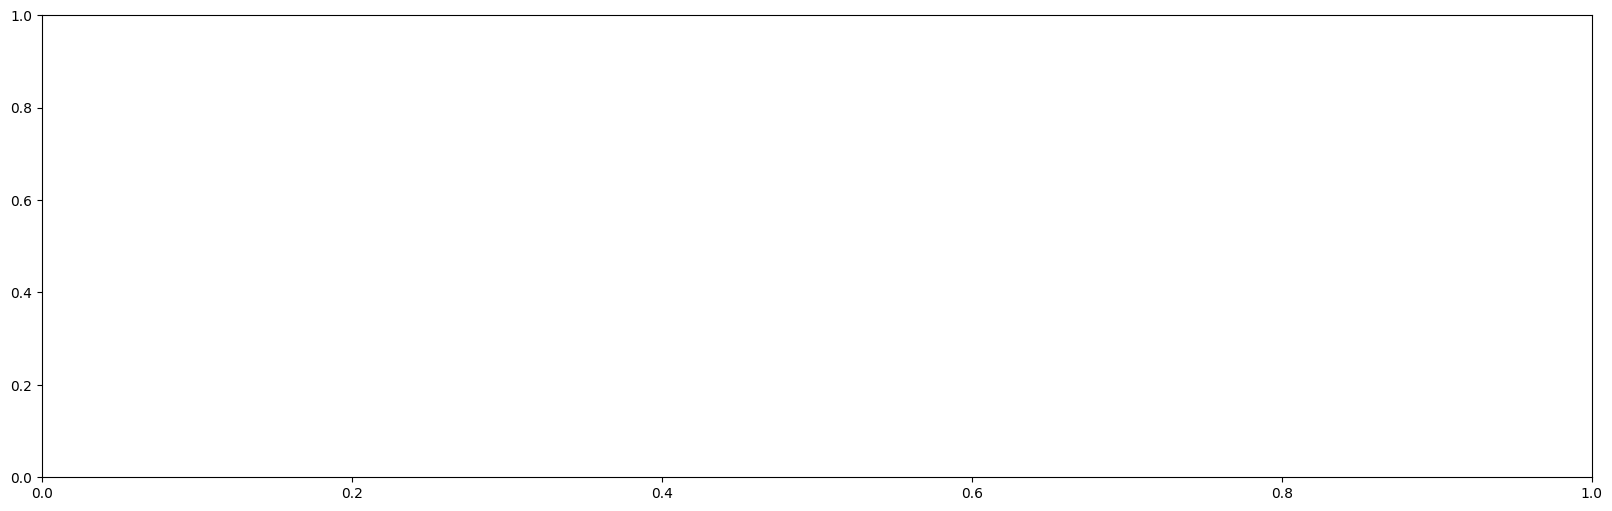

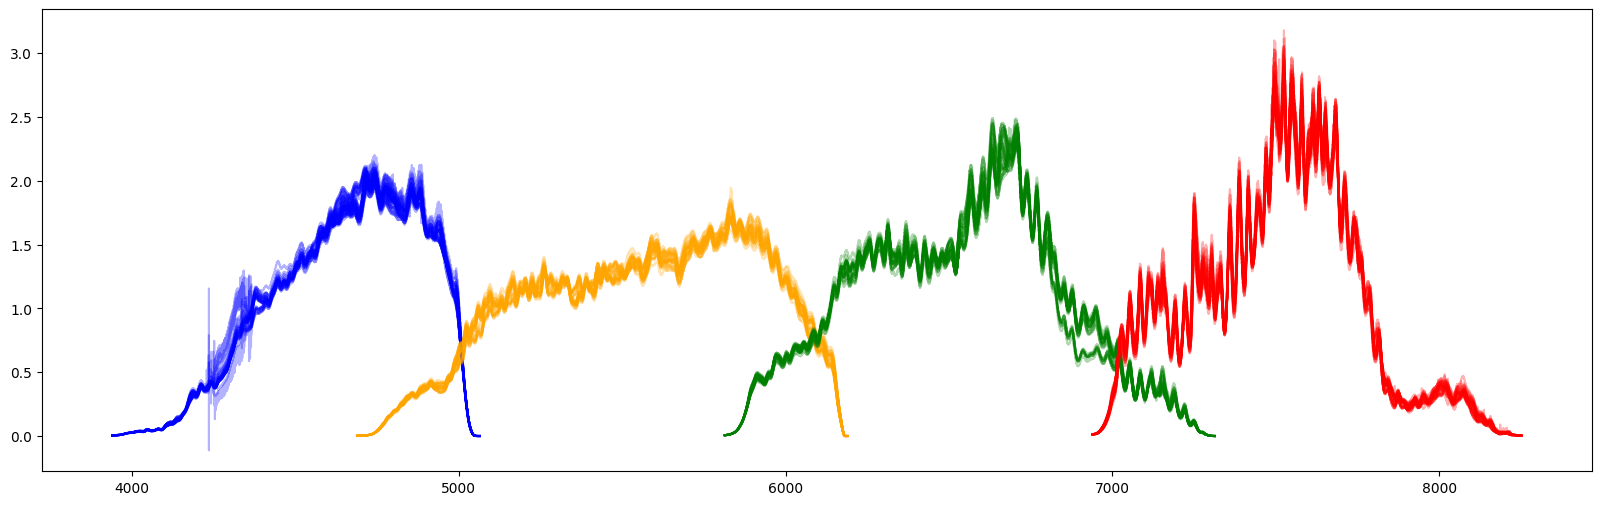

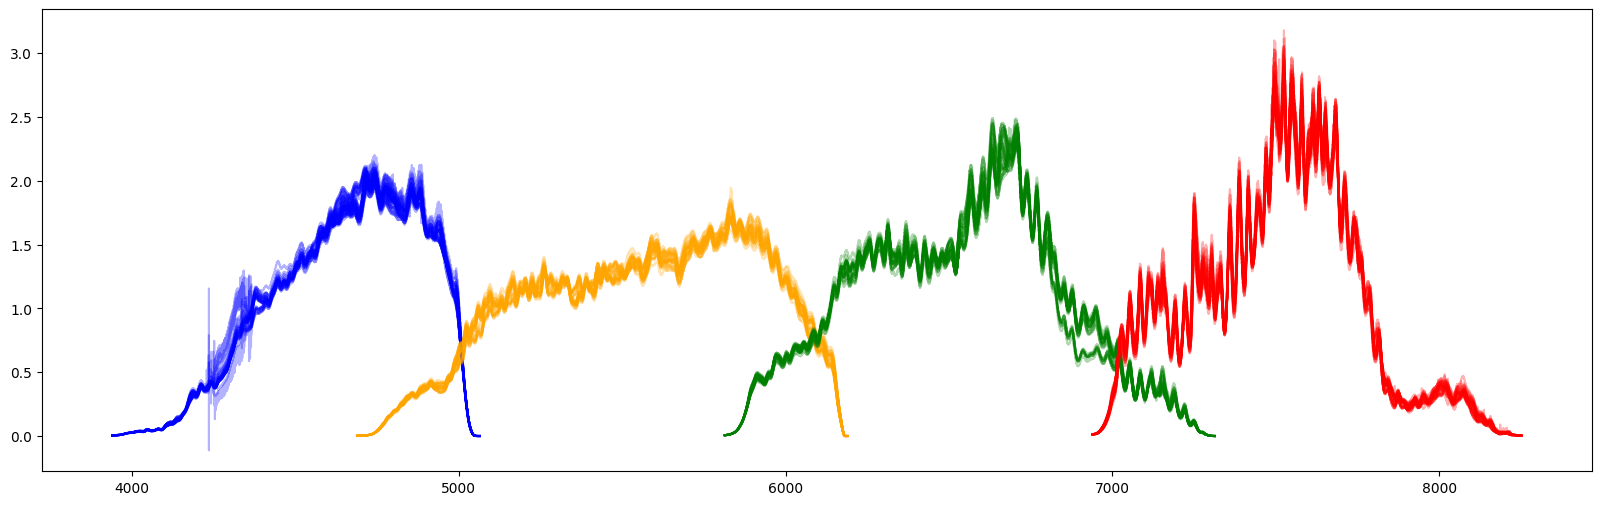

In [83]:
colors = ['blue', 'orange', 'green', 'red']
fig, ax = plt.subplots(figsize=(20, 6))

for bank, color in enumerate(colors):
    bank_path = os.path.join(path_to_save, str(bank))
    for epoch in os.listdir(bank_path):
        gain_path = os.path.join(bank_path, epoch, 'gain.npy')
        xs, ys = np.load(gain_path)
        ax.plot(xs, ys / np.mean(ys), color=color, alpha=0.3)

### Gains pdf

In [89]:
def plot_spectra(epoch, kind):
    fig, ax = plt.subplots(figsize=(15,6))
    colors = ['blue', 'orange', 'green', 'red']

    for bank, color in enumerate(colors):
        gain_path = os.path.join(path_to_save, str(bank), epoch, f'{kind}.npy')
        if os.path.exists(gain_path):
            xs, ys = np.load(gain_path)
            ax.plot(xs, ys, color=color)
        else:
            print(f'epoch {epoch} does not have bank {bank} data!')

    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
    ax.set_ylabel('Power', fontsize=16)
    ax.set_title(epoch, fontsize=18)

    return fig

In [90]:
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.5

epochs = cadence_group.keys()

In [92]:
pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/calibrator_scans_v2_gains.pdf')

for epoch in tqdm(epochs):
    fig = plot_spectra(epoch, 'gain')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

  0%|          | 0/36 [00:00<?, ?it/s]

epoch AGBT21B_999_27 does not have bank 3 data!
epoch AGBT23A_999_33 does not have bank 2 data!


In [93]:
pdf = PdfPages('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/calibrator_scans_v2_ONs.pdf')

for epoch in tqdm(epochs):
    fig = plot_spectra(epoch, 'ON')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

pdf.close()

  0%|          | 0/36 [00:00<?, ?it/s]

epoch AGBT21B_999_27 does not have bank 3 data!
epoch AGBT23A_999_33 does not have bank 2 data!
